# Belief Update Analysis

This notebook provides three analyses:

1. **Simplex plots** for a single model: theoretical vs. retrieved simplexes for the linear, full, and constrained belief updates.
2. **MSE comparison** across multiple models, with the Theorem 4.2 error bound overlaid as colour.
3. **Explained-variance table** (3, 4, 5 PCA components) across multiple models.

> **Hook convention used throughout**
> - Constrained belief update  → `blocks.<last_layer>.hook_resid_mid`  (after attention, before MLP)
> - Linear / Full belief update → `blocks.<last_layer>.hook_resid_post` (after MLP)

In [ ]:
%load_ext autoreload
%autoreload 2

import pathlib
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

from epsilon_transformers.persistence import Persister
from epsilon_transformers.process.processes import Linear_Mess3, Mess3
from epsilon_transformers.analysis.simplex_analysis import SimplexAnalyzer
from epsilon_transformers.visualization.plots import _project_to_simplex

# ── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = 'cuda:0'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Using device: {device}')

---
## Shared helpers

In [ ]:
# ── Helpers ──────────────────────────────────────────────────────────────────

def load_model_and_config(model_dir: str | pathlib.Path):
    """Load the final checkpoint and train_config from a model directory."""
    persister = Persister(model_dir)
    model = persister.load_final_model(device=device)
    model.eval()
    config = persister.load_training_config()
    return model, config


def make_process(config: dict):
    """Instantiate Linear_Mess3 from a train_config dict."""
    params = config['dataset']['process_params']
    x = params.get('x', 0.15)
    a = params.get('a', 0.6)
    return Linear_Mess3(x=x, a=a)


def make_full_process(config: dict):
    """Instantiate Mess3 (non-linear) from a train_config dict."""
    params = config['dataset']['process_params']
    x = params.get('x', 0.15)
    a = params.get('a', 0.6)
    return Mess3(x=x, a=a)


def last_layer_hooks(model):
    """Return resid_mid and resid_post hook names for the final layer."""
    n = model.cfg.n_layers - 1
    return (
        f'blocks.{n}.hook_resid_mid',   # after attn, before MLP  → constrained
        f'blocks.{n}.hook_resid_post',  # after MLP               → linear / full
    )


def error_bound_avg(x_val: float, a_val: float, d_max: int = 9) -> float:
    """Theorem 4.2 error bound averaged over d = 0 … d_max.
    
    Bound: ||eta - r_lin||_1 <= 2*(rho-1)/rho * (1-(1-3x)^d)/(3x)
    Factor of 2 because ||p-q||_1 = 2*TV and TV <= (rho-1)/rho.
    """
    b = (1 - a_val) / 2
    y = 1 - 2 * x_val
    p_dom = a_val * y + 2 * b * x_val
    p_off = a_val * x_val + b * (1 - x_val)
    rho = p_dom / p_off if p_off > 1e-12 else 1.0
    q = max((rho - 1) / rho, 0.0)   # TV-distance factor; multiply by 2 for L1
    lam = 1 - 3 * x_val
    total = 0.0
    for d in range(d_max + 1):
        if d == 0:
            total += 0.0
        else:
            denom = 3 * x_val
            accum = (1 - lam**d) / denom if abs(x_val) > 1e-9 else float(d)
            total += 2 * q * accum   # factor 2: ||p-q||_1 = 2*TV
    return total / (d_max + 1)



def plot_simplex_bg(ax):
    """Draw the equilateral triangle outline on a white-background axis."""
    tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])
    ax.plot(tri[:, 0], tri[:, 1], 'k-', lw=1.0, alpha=0.4)
    ax.set_aspect('equal')
    ax.axis('off')


def scatter_simplex(ax, beliefs, title, color='steelblue', alpha=0.15, s=3):
    """Project belief array [N, 3] to 2-D simplex and scatter plot.
    
    If color is 'rgb', uses the belief values directly as RGB colours
    (normalised to [0, 1] per-channel), matching the style in
    simplex_analysis_mess3.ipynb.
    """
    bx, by = _project_to_simplex(beliefs)
    if color == 'rgb':
        v_min, v_max = beliefs.min(), beliefs.max()
        c = (beliefs - v_min) / (v_max - v_min + 1e-12)
        ax.scatter(bx, by, s=s, alpha=alpha, c=c, linewidths=0)
    else:
        ax.scatter(bx, by, s=s, alpha=alpha, c=color, linewidths=0)
    plot_simplex_bg(ax)
    ax.set_title(title, fontsize=10, pad=4, color='black')


def get_activations_flat(model, inputs: torch.Tensor, hook: str) -> np.ndarray:
    """Run model on inputs and return activations at hook, flattened to [B*T, D]."""
    with torch.no_grad():
        inp = inputs.to(device)
        _, cache = model.run_with_cache(inp, names_filter=lambda x: x == hook)
    acts = cache[hook]  # [B, T, D]
    return acts.reshape(-1, acts.shape[-1]).cpu().numpy()


def fit_probe(acts_flat: np.ndarray, beliefs_flat: np.ndarray):
    """Linear regression: activations → beliefs."""
    reg = LinearRegression()
    reg.fit(acts_flat, beliefs_flat)
    pred = reg.predict(acts_flat)
    return pred, reg


def compute_mse_simplex(true_flat, pred_flat):
    """MSE in 2-D simplex coordinates."""
    tx, ty = _project_to_simplex(true_flat)
    px, py = _project_to_simplex(pred_flat)
    return float(np.mean((tx - px)**2 + (ty - py)**2))


def explained_variance_pca(acts_flat: np.ndarray, n_components_list=(3, 4, 5)):
    """Return cumulative explained variance ratio for each n_components."""
    results = {}
    for n in n_components_list:
        pca = PCA(n_components=n)
        pca.fit(acts_flat)
        results[n] = float(np.sum(pca.explained_variance_ratio_))
    return results

print('Helpers loaded.')

---
## Part 1 — Simplex plots for a single model

Set `MODEL_DIR` to your checkpoint directory.

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
MODEL_DIR = pathlib.Path(
    '/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/2_layer_0.2_0.5_linearmess3_1e-2'
)
DEPTH = 11   # tree depth = context length + 1

# ── Load model & process ──────────────────────────────────────────────────────
model, config = load_model_and_config(MODEL_DIR)
process_lin  = make_process(config)       # Linear_Mess3 (for linear + constrained)
process_full = make_full_process(config)  # Mess3         (for full Bayesian)

hook_mid, hook_post = last_layer_hooks(model)
x_val = config['dataset']['process_params']['x']
a_val = config['dataset']['process_params']['a']
print(f'Parameters: x={x_val}, alpha={a_val}')
print(f'Constrained hook : {hook_mid}')
print(f'Linear/Full hook : {hook_post}')

[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/2_layer_0.2_0.5_linearmess3_1e-2
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/2_layer_0.2_0.5_linearmess3_1e-2
Parameters: x=0.5, alpha=0.2
Constrained hook : blocks.1.hook_resid_mid
Linear/Full hook : blocks.1.hook_resid_post


In [5]:
# ── Build theoretical beliefs from ONE canonical set of input sequences ─────
#
# KEY FIX: all three belief arrays MUST come from the SAME sequences.
# We build paths once (setup_from_tree on process_lin), then call the
# internal belief-computation methods directly on those same inputs for
# the full-Bayesian and constrained updates.

# 1. Canonical paths — use Linear_Mess3 tree (same topology as Mess3)
sa_lin = SimplexAnalyzer(hook=hook_post, device=device)
sa_lin.setup_from_tree(process_lin, depth=DEPTH, constrained=False)
inputs         = sa_lin.test_inputs            # [N, T] — shared by all
linear_beliefs = sa_lin.test_beliefs_flat      # [N*T, 3]

# 2. Full Bayesian beliefs — same inputs, Mess3 (no norm_transition_matrix
#    → _compute_beliefs_for_batch falls back to raw T^(z) + renorm, which
#      is exactly the full Bayesian update  η_new = η T^(z) / (η T^(z) 1))
full_tensor    = sa_lin._compute_beliefs_for_batch(inputs, process_full)
full_beliefs   = full_tensor.reshape(-1, full_tensor.shape[-1]).cpu().numpy()  # [N*T, 3]

# 3. Constrained beliefs — same inputs, Linear_Mess3
con_tensor          = sa_lin._compute_constrained_beliefs_for_batch(inputs, process_lin)
constrained_beliefs = con_tensor.reshape(-1, con_tensor.shape[-1]).cpu().numpy()  # [N*T, 3]

print(f'Sequences: {inputs.shape[0]}, context len: {inputs.shape[1]}')
print(f'linear_beliefs      : {linear_beliefs.shape}')
print(f'full_beliefs        : {full_beliefs.shape}')
print(f'constrained_beliefs : {constrained_beliefs.shape}')


Sequences: 59049, context len: 10
linear_beliefs      : (590490, 3)
full_beliefs        : (590490, 3)
constrained_beliefs : (590490, 3)


In [6]:
# ── Get model activations & fit probes ────────────────────────────────────
# All three probes use the same 'inputs', so activations[i] ↔ beliefs[i].

# resid_post → linear & full probes  (after MLP)
acts_post      = get_activations_flat(model, inputs, hook_post)
retrieved_lin,  _ = fit_probe(acts_post, linear_beliefs)
retrieved_full, _ = fit_probe(acts_post, full_beliefs)

# resid_mid  → constrained probe  (after attention, before MLP)
acts_mid       = get_activations_flat(model, inputs, hook_mid)
retrieved_con,  _ = fit_probe(acts_mid, constrained_beliefs)

print('Probes fitted.')
print(f'acts_post shape : {acts_post.shape}')
print(f'acts_mid  shape : {acts_mid.shape}')


Probes fitted.
acts_post shape : (590490, 64)
acts_mid  shape : (590490, 64)


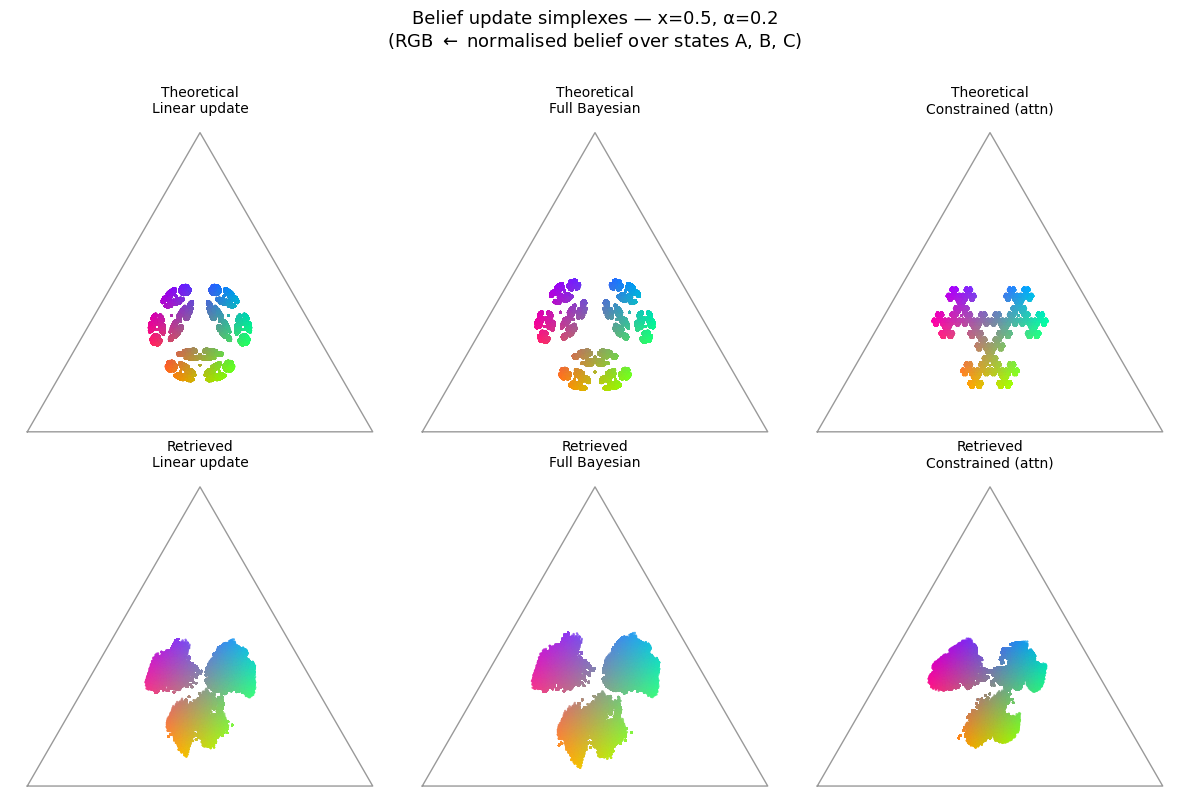

Saved simplex_comparison.pdf/png


In [7]:
# ── Plot 6-panel simplex grid ─────────────────────────────────────────────────
#
#  Row 0: theoretical simplexes   (RGB-coloured by belief state)
#  Row 1: retrieved (model) simplexes
#
#  Col 0: Linear update
#  Col 1: Full Bayesian update
#  Col 2: Constrained update
#
#  Colour encoding: each point's (R, G, B) = normalised belief over states A, B, C.
#  This matches the style used in simplex_analysis_mess3.ipynb.

fig, axes = plt.subplots(2, 3, figsize=(12, 8), facecolor='white')
fig.subplots_adjust(hspace=0.05, wspace=0.05)

pairs = [
    (linear_beliefs,      retrieved_lin,  'Linear update'),
    (full_beliefs,        retrieved_full, 'Full Bayesian'),
    (constrained_beliefs, retrieved_con,  'Constrained (attn)'),
]

for col, (theory, retrieved, title) in enumerate(pairs):
    # theoretical
    ax = axes[0, col]
    ax.set_facecolor('white')
    scatter_simplex(ax, theory, f'Theoretical\n{title}', color='rgb', alpha=0.8, s=3)

    # retrieved
    ax = axes[1, col]
    ax.set_facecolor('white')
    scatter_simplex(ax, retrieved, f'Retrieved\n{title}', color='rgb', alpha=0.8, s=3)

# row labels
for row_label, ax in zip(['Theoretical', 'Retrieved (model)'], axes[:, 0]):
    ax.set_ylabel(row_label, color='black', fontsize=11, labelpad=6)
    ax.yaxis.label.set_visible(True)

fig.suptitle(
    f'Belief update simplexes — x={x_val}, α={a_val}\n'
    r'(RGB $\leftarrow$ normalised belief over states A, B, C)',
    color='black', fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'simplex_comparison.pdf', bbox_inches='tight', facecolor='white')
plt.savefig(MODEL_DIR / 'simplex_comparison.png', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()
print('Saved simplex_comparison.pdf/png')

---
## Part 2 — MSE across multiple models (coloured by error bound)

Add paths to all model directories you want to compare.

In [14]:
# ── List of model dirs to compare ─────────────────────────────────────────────
MODEL_DIRS = [
    # pathlib.Path('/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.02_0.9'),
    # pathlib.Path('/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.25_0.5'),
    pathlib.Path('/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.15_0.6'),
    pathlib.Path('/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.1_0.7'),
    # pathlib.Path('/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/2_layer_0.5_0.2_lr1e-2_2b_ckpt4k'),
    pathlib.Path('/Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.28_0.85'),

    # Add more paths here, e.g.:
    # pathlib.Path('../report_models/1_layer_0.15_0.6_linearmess3_1e-2'),
]

DEPTH_MULTI = 11

In [ ]:
# ── Compute metrics for every model ──────────────────────────────────────────

rows = []

for mdir in MODEL_DIRS:
    print(f'\n=== {mdir.name} ===')
    m, cfg = load_model_and_config(mdir)
    p_lin  = make_process(cfg)        # Linear_Mess3
    p_full = make_full_process(cfg)   # Mess3

    x_v = cfg['dataset']['process_params']['x']
    a_v = cfg['dataset']['process_params']['a']
    bound = error_bound_avg(x_v, a_v)
    h_mid, h_post = last_layer_hooks(m)

    # 1. One canonical set of paths (Linear_Mess3 tree)
    sa = SimplexAnalyzer(hook=h_post, device=device)
    sa.setup_from_tree(p_lin, depth=DEPTH_MULTI, constrained=False)
    inp      = sa.test_inputs          # shared by all
    lin_true = sa.test_beliefs_flat    # [N*T, 3]

    # 2. Full Bayesian beliefs — same inp, Mess3 process
    full_tensor = sa._compute_beliefs_for_batch(inp, p_full)
    full_true   = full_tensor.reshape(-1, full_tensor.shape[-1]).cpu().numpy()

    # 3. Activations — same inp for both hooks
    acts = get_activations_flat(m, inp, h_post)

    lin_pred,  _ = fit_probe(acts, lin_true)
    full_pred, _ = fit_probe(acts, full_true)

    rows.append(dict(
        name=mdir.name,
        x=x_v,
        alpha=a_v,
        error_bound=bound,
        lin_mse=compute_mse_simplex(lin_true, lin_pred),
        full_mse=compute_mse_simplex(full_true, full_pred),
    ))
    print(f'  error_bound={bound:.4f}  lin_mse={rows[-1]["lin_mse"]:.6f}  full_mse={rows[-1]["full_mse"]:.6f}')

df = pd.DataFrame(rows)
print('\n', df.to_string(index=False))


In [ ]:
# ── Plotly figure: MSE ─────────────────────────────────────────────────────
import plotly.graph_objects as go
import plotly.io as pio

n_models = len(df)
xs       = list(range(n_models))
labels   = df['name'].tolist()
bounds   = df['error_bound'].tolist()

jitter = 0.0   # horizontal offset so Lin and Full don't overlap

def make_figure(col_lin, col_full, ylabel, filename):
    fig = go.Figure()

    # ── Linear update (circles) ───────────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=[x - jitter for x in xs],
        y=df[col_lin].tolist(),
        mode='markers',
        name='Linear update',
        marker=dict(
            symbol='circle',
            size=14,
            color=bounds,
            colorscale='Inferno',
            showscale=True,
            colorbar=dict(
                title=dict(text='Avg error bound<br>(Thm 4.2, d=0–9)', side='right'),
                thickness=15,
                len=0.75,
                x=1.02,
            ),
            line=dict(color='white', width=1),
        ),
        customdata=[[lbl, b] for lbl, b in zip(labels, bounds)],
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            + ylabel + ': %{y:.6f}<br>'
            'Error bound: %{customdata[1]:.4f}<extra>Linear</extra>'
        ),
    ))

    # ── Full Bayesian (X markers) ─────────────────────────────────────────
    fig.add_trace(go.Scatter(
        x=[x + jitter for x in xs],
        y=df[col_full].tolist(),
        mode='markers',
        name='Full Bayesian',
        marker=dict(
            symbol='x',
            size=14,
            color=bounds,
            colorscale='Inferno',
            showscale=False,   # share colorbar with first trace
            line=dict(color='white', width=1),
        ),
        customdata=[[lbl, b] for lbl, b in zip(labels, bounds)],
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            + ylabel + ': %{y:.6f}<br>'
            'Error bound: %{customdata[1]:.4f}<extra>Full Bayesian</extra>'
        ),
    ))

    fig.update_layout(
        title=dict(text=f'<b>{ylabel} — Linear vs Full Bayesian</b>', x=0.5),
        xaxis=dict(
            tickmode='array',
            tickvals=xs,
            ticktext=labels,
            tickangle=-35,
            title='Model',
            gridcolor='rgba(200,200,200,0.3)',
        ),
        yaxis=dict(
            title=ylabel,
            gridcolor='rgba(200,200,200,0.3)',
        ),
        legend=dict(
            x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)',
            bordercolor='lightgrey', borderwidth=1,
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        width=max(600, n_models * 120 + 250),
        height=480,
        margin=dict(l=70, r=130, t=60, b=120),
    )
    fig.show()
    fig.write_html(filename + '.html')
    fig.write_image(filename + '.png', scale=2)
    print(f'Saved {filename}.html / .png')

make_figure('lin_mse', 'full_mse', 'MSE (2-D simplex)', 'model_mse')


---
## Part 3 — Explained variance in 3, 4, 5 PCA components

In [12]:
# ── Compute PCA explained variance for every model ────────────────────────────

pca_rows = []

for mdir in MODEL_DIRS:
    print(f'PCA: {mdir.name}')
    m, cfg = load_model_and_config(mdir)
    p_lin = make_process(cfg)    # Linear_Mess3

    x_v = cfg['dataset']['process_params']['x']
    a_v = cfg['dataset']['process_params']['a']
    bound = error_bound_avg(x_v, a_v)
    _, h_post = last_layer_hooks(m)

    # One canonical set of paths — same fix as Parts 1 & 2
    sa = SimplexAnalyzer(hook=h_post, device=device)
    sa.setup_from_tree(p_lin, depth=DEPTH_MULTI, constrained=False)
    acts = get_activations_flat(m, sa.test_inputs, h_post)

    ev = explained_variance_pca(acts, n_components_list=(3, 4, 5,6))

    pca_rows.append(dict(
        model=mdir.name,
        x=x_v,
        alpha=a_v,
        error_bound=round(bound, 4),
        **{f'ev_{k}': round(v, 4) for k, v in ev.items()},
    ))

df_pca = pd.DataFrame(pca_rows)
df_pca.columns = [
    'Model', 'x', 'α', 'Avg error bound',
    'Expl. var. (3 PCs)', 'Expl. var. (4 PCs)', 'Expl. var. (5 PCs)', 'Expl. var. (6 PCs)'
]
print(df_pca.to_string(index=False))


PCA: 0.25_0.5
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.25_0.5
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.25_0.5
PCA: 0.15_0.6
[Persister] Found 3 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.15_0.6
[Persister] Found 3 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.15_0.6
PCA: stage_0.1_0.7
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.1_0.7
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.1_0.7
PCA: stage_0.28_0.85
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.28_0.85
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.28_0.85
    

In [13]:
# ── Render as styled table ────────────────────────────────────────────────────
from IPython.display import display

styled = (
    df_pca.style
    .background_gradient(subset=['Expl. var. (3 PCs)', 'Expl. var. (4 PCs)', 'Expl. var. (5 PCs)'],
                         cmap='YlGn', vmin=0, vmax=1)
    .background_gradient(subset=['Avg error bound'], cmap='YlOrRd_r')
    .format({
        'Expl. var. (3 PCs)': '{:.3f}',
        'Expl. var. (4 PCs)': '{:.3f}',
        'Expl. var. (5 PCs)': '{:.3f}',
        'Avg error bound':    '{:.4f}',
    })
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-size', '11px'), ('text-align', 'center')]
    }])
    .set_caption('Explained variance by PCA components in residual_post activations')
)

display(styled)

,Model,x,α,Avg error bound,Expl. var. (3 PCs),Expl. var. (4 PCs),Expl. var. (5 PCs),Expl. var. (6 PCs)
0,0.25_0.5,0.250000,0.500000,0.3852,0.993,0.995,0.996,0.996900
1,0.15_0.6,0.150000,0.600000,1.5855,0.996,0.998,0.999,0.998900
2,stage_0.1_0.7,0.100000,0.700000,2.9411,0.989,0.992,0.995,0.996000
3,stage_0.28_0.85,0.280000,0.850000,0.6252,1.000,1.000,1.000,0.999800


---
## Part 4 — Simplex gallery across model parameterisations

For every model in `MODEL_DIRS` one row of **6 panels** is produced:

| Col | Content |
|-----|---------|
| 1 | Theoretical Full (Mess3 Bayesian) |
| 2 | Obtained Full (linear probe, `resid_post`) |
| 3 | Theoretical Linear (Linear_Mess3) |
| 4 | Obtained Linear (linear probe, `resid_post`) |
| 5 | Theoretical Constrained (Linear_Mess3, constrained update) |
| 6 | Obtained Constrained (linear probe, `resid_mid`) |

All panels use the RGB-belief colouring from `simplex_analysis_mess3.ipynb`.


=== 0.15_0.6 ===
[Persister] Found 3 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.15_0.6
[Persister] Found 3 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.15_0.6


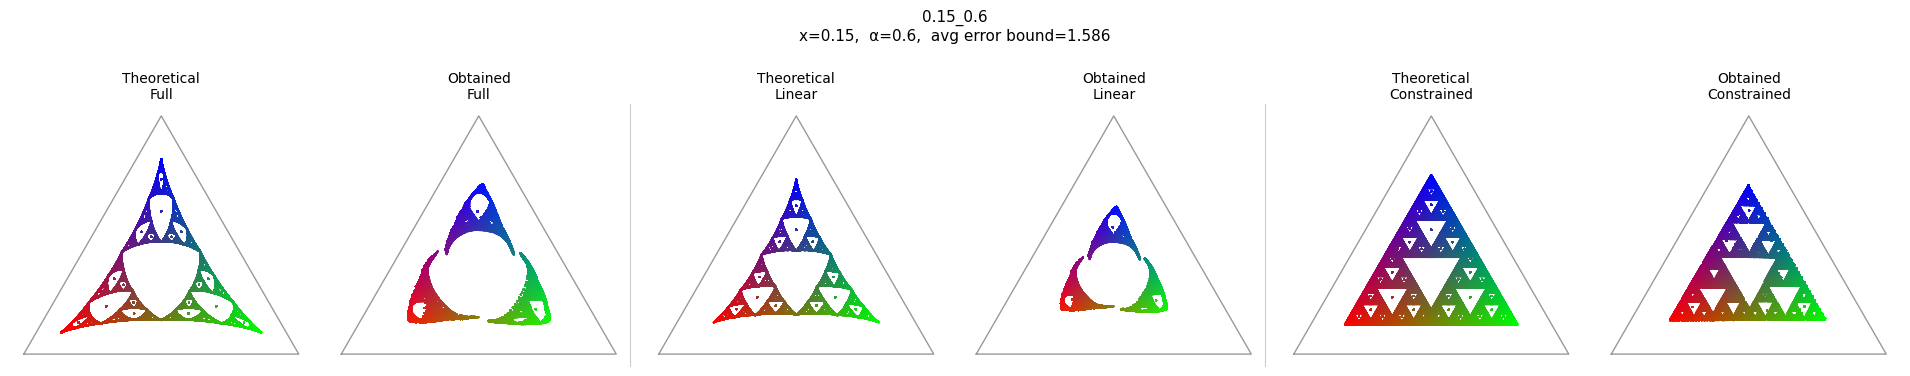

  Saved → /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/0.15_0.6/simplex_gallery.png

=== stage_0.1_0.7 ===
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.1_0.7
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.1_0.7


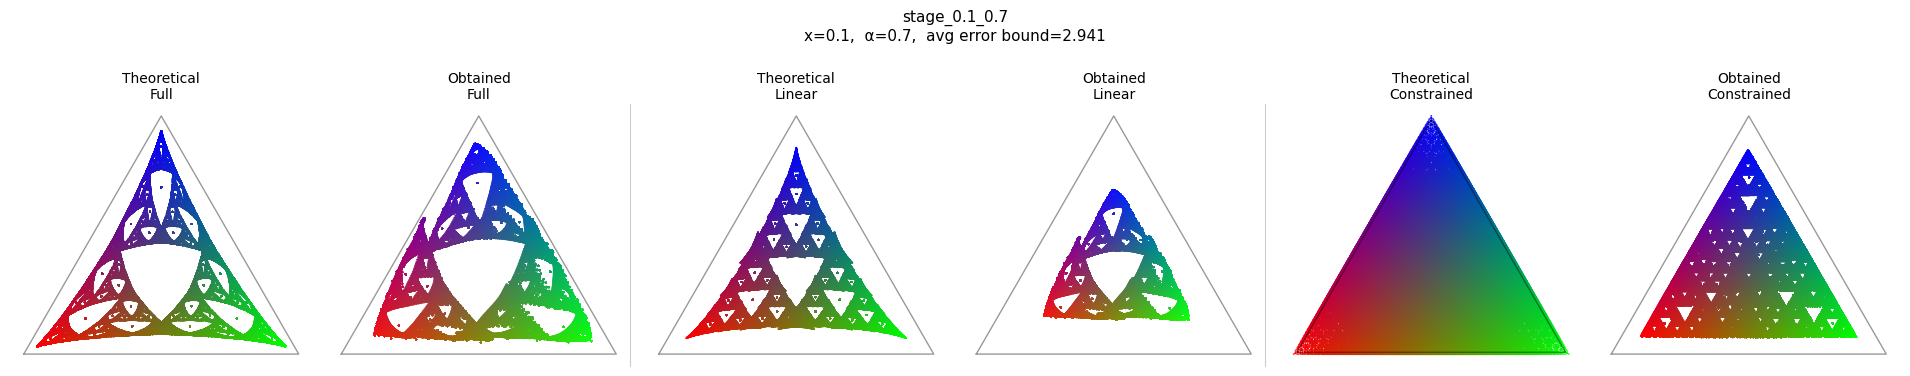

  Saved → /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.1_0.7/simplex_gallery.png

=== stage_0.28_0.85 ===
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.28_0.85
[Persister] Found 1 checkpoints in /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.28_0.85


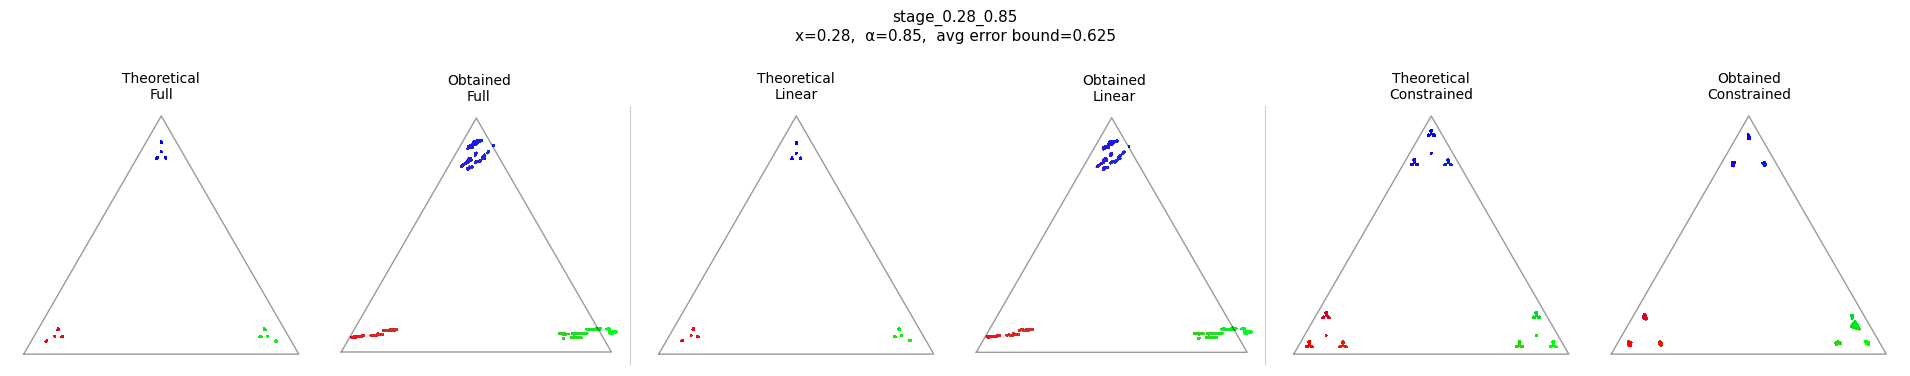

  Saved → /Users/sbhandari/Documents/GitHub/epsilon-transformers/report_models/stage_0.28_0.85/simplex_gallery.png


In [15]:
# ── Part 4: Simplex gallery — one row of 6 panels per model ──────────────────
#
#  Col layout (left → right):
#    0  Theoretical Full      (Mess3 Bayesian update)
#    1  Obtained Full         (linear probe from resid_post)
#    2  Theoretical Linear    (Linear_Mess3 update)
#    3  Obtained Linear       (linear probe from resid_post)
#    4  Theoretical Constrained (Linear_Mess3, constrained)
#    5  Obtained Constrained  (linear probe from resid_mid)

COL_TITLES = [
    'Theoretical\nFull',
    'Obtained\nFull',
    'Theoretical\nLinear',
    'Obtained\nLinear',
    'Theoretical\nConstrained',
    'Obtained\nConstrained',
]

N_COLS = len(COL_TITLES)
PANEL_SIZE = 3.2   # inches per panel (square)

for mdir in MODEL_DIRS:
    print(f'\n=== {mdir.name} ===')
    m, cfg = load_model_and_config(mdir)
    p_lin  = make_process(cfg)        # Linear_Mess3
    p_full = make_full_process(cfg)   # Mess3
    h_mid, h_post = last_layer_hooks(m)

    x_v = cfg['dataset']['process_params']['x']
    a_v = cfg['dataset']['process_params']['a']
    bound = error_bound_avg(x_v, a_v)

    # ── 1. Build canonical path set from Linear_Mess3 tree ──────────────────
    sa = SimplexAnalyzer(hook=h_post, device=device)
    sa.setup_from_tree(p_lin, depth=DEPTH_MULTI, constrained=False)
    inp = sa.test_inputs                          # [N, T], shared by all

    # ── 2. Theoretical beliefs ───────────────────────────────────────────────
    lin_true  = sa.test_beliefs_flat              # [N*T, 3]  Linear_Mess3

    full_tensor = sa._compute_beliefs_for_batch(inp, p_full)
    full_true   = full_tensor.reshape(-1, full_tensor.shape[-1]).cpu().numpy()

    con_tensor = sa._compute_constrained_beliefs_for_batch(inp, p_lin)
    con_true   = con_tensor.reshape(-1, con_tensor.shape[-1]).cpu().numpy()

    # ── 3. Obtained beliefs (linear probe) ──────────────────────────────────
    acts_post = get_activations_flat(m, inp, h_post)
    acts_mid  = get_activations_flat(m, inp, h_mid)

    full_pred, _ = fit_probe(acts_post, full_true)
    lin_pred,  _ = fit_probe(acts_post, lin_true)
    con_pred,  _ = fit_probe(acts_mid,  con_true)

    # ── 4. Plot ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, N_COLS,
        figsize=(PANEL_SIZE * N_COLS, PANEL_SIZE + 0.6),
        facecolor='white'
    )
    fig.subplots_adjust(wspace=0.04)

    panels = [
        full_true,   # 0 Theoretical Full
        full_pred,   # 1 Obtained    Full
        lin_true,    # 2 Theoretical Linear
        lin_pred,    # 3 Obtained    Linear
        con_true,    # 4 Theoretical Constrained
        con_pred,    # 5 Obtained    Constrained
    ]

    for col, (beliefs, title) in enumerate(zip(panels, COL_TITLES)):
        ax = axes[col]
        ax.set_facecolor('white')
        scatter_simplex(ax, beliefs, title, color='rgb', alpha=0.75, s=2)
        # light vertical separator after each "obtained" panel
        if col in (1, 3):
            ax.plot([1, 1], [0, 1], color='#cccccc', lw=0.8,
                    transform=ax.transAxes, clip_on=False)

    fig.suptitle(
        f'{mdir.name}\n' 
        f'x={x_v},  α={a_v},  avg error bound={bound:.3f}',
        fontsize=11, color='black', y=1.03
    )
    plt.tight_layout()

    out_pdf = mdir / 'simplex_gallery.pdf'
    out_png = mdir / 'simplex_gallery.png'
    plt.savefig(out_pdf, bbox_inches='tight', facecolor='white')
    plt.savefig(out_png, bbox_inches='tight', facecolor='white', dpi=150)
    plt.show()
    print(f'  Saved → {out_png}')
